#INSTALLAZIONE DELLE LIBRERIE E DEI MODULI NECESSARI

In [1]:
pip install yfinance

In [2]:
import yfinance as yf

In [3]:
import csv

In [4]:
from datetime import datetime

In [5]:
# @title Scarica i dati da Yahoo Finance

Ticker = "MSFT" # @param {type: "string"}
Nome_csv = "Microsoft" # @param {type: "string"}

asset = yf.download(Ticker, period="max", actions=True)

asset.to_csv(f"{Nome_csv}.csv")

print("\nControlla la cartella Content")

/tmp/ipykernel_701/2984741732.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset = yf.download(Ticker, period="max", actions=True)
[*********************100%***********************]  1 of 1 completed



Controlla la cartella Content


#Definizione delle funzioni

In [6]:
def date_list(nome_file):

  """
  La funzione ci permette di estrarre le date dal file csv e racchiuderle in una lista
  Non richiede alcun argomento, i dati necessari sono già richiamati
  """

  date = []

  with open(f"{nome_file}.csv", "r") as Ticker:
   titolo = csv.reader(Ticker)

   titolo = list(titolo)

   titolo.pop(1)
   titolo.pop(1)
   titolo[0][0] = "Date"

  for i in titolo:
        date.append(i[0])

  date.pop(0)
  return date

def years_list(a):

  """
  La funzione ci permette di estrarre gli anni di ciascuna data e racchiuderle in una lista
  E' necessario passare alla funzione la lista delle date (a)
  """

  anni = []
  d = a.copy()
  for i in range(len(d)):
    d[i] = datetime.strptime(d[i],"%Y-%m-%d")
    anno = datetime.isocalendar(d[i]).year
    anni.append(anno)
  return anni

def week_list(a):

  """
  La funzione ci permette di estrarre la settimana corrispondente di ciascuna data e racchiuderle in una lista
  E' necessario passare alla funzione la lista delle date (a)
  """

  week = []
  d = a.copy()
  for i in range(len(d)):
    d[i] = datetime.strptime(d[i],"%Y-%m-%d")
    settimana = datetime.isocalendar(d[i]).week
    week.append(settimana)
  return week

In [7]:
def close_slist():

  """
  La funzione ci permette di estrarre i prezzi di chiusura giornalieri e racchiuderli in una lista
  Non richiede alcun argomento, i dati necessari sono già richiamati
  """

  close_t_string = []

  with open(f"{Nome_csv}.csv", "r") as Ticker:
    titolo = csv.reader(Ticker)

    titolo = list(titolo)

    titolo.pop(1)
    titolo.pop(1)
    titolo[0][0] = "Date"

  for i in titolo:
    close_t_string.append(i[1])

  close_t_string.pop(0)
  return close_t_string

def close_nlist(b):

  """
  La funzione ci permette di trasformare da stringa a float i prezzi di chiusura giornalieri
  E' necessario passare alla funzione la lista dei prezzi di chiusura  (b)
  """

  close_t = []

  for i in range(len(b)):
    close = float(b[i])
    close_t.append(close)
  return close_t

In [8]:
def dataset_r (w,d,a):

  """
  La funzione ci permette di creare un dataset contenente:
  - data inizio settimana (data_is)
  - data fine settimana (data_fs)
  - numero della settimana relativo alle date precedenti (n_settimana)
  - prezzo di chiusura della settimana (close_settimana)
  - rendimento settimanale di ciascuna settimana (r_week)

  E' necessario passare alla funzione:
  (w) = lista delle settimane
  (d) = lista dei prezzi di chiusura giornalieri
  (a) = lista delle date
  """

  n_settimana = []
  close_settimana = []
  data_fs = []
  data_is = []

  for i in range(len(w)):
    if i==len(w)-1 or w[i]!=w[i+1]:
      n_settimana.append(w[i])
      close_settimana.append(d[i])
      data_fs.append(a[i])
    if i==0 or w[i]!=w[i-1]:
      data_is.append(a[i])

  r_week = []

  for i in range(len(close_settimana)):
    if i==0:
      r_week.append(0)
    else:
      rendimenti = (close_settimana[i]-close_settimana[i-1])/close_settimana[i-1]
      r_week.append(rendimenti)

  n = []

  for i in range(len(n_settimana)):
    value = []
    value.append(data_is[i])
    value.append(data_fs[i])
    value.append(n_settimana[i])
    value.append(close_settimana[i])
    value.append(r_week[i])
    n.append(value)

  return n

#Definizione delle variabili

In [9]:
lista_date = date_list(Nome_csv)

print(lista_date)

['1986-03-13', '1986-03-14', '1986-03-17', '1986-03-18', '1986-03-19', '1986-03-20', '1986-03-21', '1986-03-24', '1986-03-25', '1986-03-26', '1986-03-27', '1986-03-31', '1986-04-01', '1986-04-02', '1986-04-03', '1986-04-04', '1986-04-07', '1986-04-08', '1986-04-09', '1986-04-10', '1986-04-11', '1986-04-14', '1986-04-15', '1986-04-16', '1986-04-17', '1986-04-18', '1986-04-21', '1986-04-22', '1986-04-23', '1986-04-24', '1986-04-25', '1986-04-28', '1986-04-29', '1986-04-30', '1986-05-01', '1986-05-02', '1986-05-05', '1986-05-06', '1986-05-07', '1986-05-08', '1986-05-09', '1986-05-12', '1986-05-13', '1986-05-14', '1986-05-15', '1986-05-16', '1986-05-19', '1986-05-20', '1986-05-21', '1986-05-22', '1986-05-23', '1986-05-27', '1986-05-28', '1986-05-29', '1986-05-30', '1986-06-02', '1986-06-03', '1986-06-04', '1986-06-05', '1986-06-06', '1986-06-09', '1986-06-10', '1986-06-11', '1986-06-12', '1986-06-13', '1986-06-16', '1986-06-17', '1986-06-18', '1986-06-19', '1986-06-20', '1986-06-23', '1986

In [10]:
lista_anni = years_list(lista_date)
print(lista_anni)

[1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 198

In [11]:
lista_settimane = week_list(lista_date)
print(lista_settimane)

[11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 22, 22, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 24, 24, 25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 27, 27, 27, 27, 28, 28, 28, 28, 28, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30, 31, 31, 31, 31, 31, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33, 34, 34, 34, 34, 34, 35, 35, 35, 35, 35, 36, 36, 36, 36, 37, 37, 37, 37, 37, 38, 38, 38, 38, 38, 39, 39, 39, 39, 39, 40, 40, 40, 40, 40, 41, 41, 41, 41, 41, 42, 42, 42, 42, 42, 43, 43, 43, 43, 43, 44, 44, 44, 44, 44, 45, 45, 45, 45, 45, 46, 46, 46, 46, 46, 47, 47, 47, 47, 47, 48, 48, 48, 48, 49, 49, 49, 49, 49, 50, 50, 50, 50, 50, 51, 51, 51, 51, 51, 52, 52, 52, 52, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 13, 13

In [12]:
lista_close = close_slist()

print(lista_close)

['0.05901426821947098', '0.06112176179885864', '0.06217611953616142', '0.06059489771723747', '0.059541136026382446', '0.05796051025390625', '0.056379836052656174', '0.054799217730760574', '0.05585295334458351', '0.0574335902929306', '0.058487359434366226', '0.05796051025390625', '0.0574335902929306', '0.05796051025390625', '0.058487359434366226', '0.058487359434366226', '0.0574335902929306', '0.05796051025390625', '0.05901426821947098', '0.059541136026382446', '0.06059489771723747', '0.06112176179885864', '0.06112176179885864', '0.06322990357875824', '0.0637567862868309', '0.06164922937750816', '0.06164922937750816', '0.06059489771723747', '0.06085836514830589', '0.06691806018352509', '0.07113370299339294', '0.0716605857014656', '0.06955243647098541', '0.0679718405008316', '0.06691806018352509', '0.06691806018352509', '0.06639118492603302', '0.06691806018352509', '0.06691806018352509', '0.06744492799043655', '0.06691806018352509', '0.06744492799043655', '0.0679718405008316', '0.0674449

In [13]:
prezzi_chiusura = close_nlist(lista_close)
print(prezzi_chiusura)

[0.05901426821947098, 0.06112176179885864, 0.06217611953616142, 0.06059489771723747, 0.059541136026382446, 0.05796051025390625, 0.056379836052656174, 0.054799217730760574, 0.05585295334458351, 0.0574335902929306, 0.058487359434366226, 0.05796051025390625, 0.0574335902929306, 0.05796051025390625, 0.058487359434366226, 0.058487359434366226, 0.0574335902929306, 0.05796051025390625, 0.05901426821947098, 0.059541136026382446, 0.06059489771723747, 0.06112176179885864, 0.06112176179885864, 0.06322990357875824, 0.0637567862868309, 0.06164922937750816, 0.06164922937750816, 0.06059489771723747, 0.06085836514830589, 0.06691806018352509, 0.07113370299339294, 0.0716605857014656, 0.06955243647098541, 0.0679718405008316, 0.06691806018352509, 0.06691806018352509, 0.06639118492603302, 0.06691806018352509, 0.06691806018352509, 0.06744492799043655, 0.06691806018352509, 0.06744492799043655, 0.0679718405008316, 0.06744492799043655, 0.06744492799043655, 0.0679718405008316, 0.06691806018352509, 0.06639118492

In [14]:
ds = dataset_r(lista_settimane, prezzi_chiusura,lista_date)

ds.pop(0)
print(ds)

[['1986-03-17', '1986-03-21', 12, 0.056379836052656174, -0.07758162733933198], ['1986-03-24', '1986-03-27', 13, 0.058487359434366226, 0.03738080010984286], ['1986-03-31', '1986-04-04', 14, 0.058487359434366226, 0.0], ['1986-04-07', '1986-04-11', 15, 0.06059489771723747, 0.03603408160760444], ['1986-04-14', '1986-04-18', 16, 0.06164922937750816, 0.017399677200391817], ['1986-04-21', '1986-04-25', 17, 0.07113370299339294, 0.1538457773382169], ['1986-04-28', '1986-05-02', 18, 0.06691806018352509, -0.05926364905056914], ['1986-05-05', '1986-05-09', 19, 0.06691806018352509, 0.0], ['1986-05-12', '1986-05-16', 20, 0.0679718405008316, 0.01574732313543593], ['1986-05-19', '1986-05-23', 21, 0.0653374046087265, -0.03875775428021361], ['1986-05-27', '1986-05-30', 22, 0.07376813143491745, 0.12903369634405307], ['1986-06-02', '1986-06-06', 23, 0.07218746840953827, -0.021427451050101954], ['1986-06-09', '1986-06-13', 24, 0.06639118492603302, -0.08029487127352114], ['1986-06-16', '1986-06-20', 25, 0.0

#Conclusione

In [18]:
import matplotlib.pyplot as plt


Data inizio settimana: 2000-03-13 00:00:00
Data fine settimana: 2000-03-17 00:00:00
Prezzo di chiusura: 30.16
Rendimento settimanale: -1.6089%


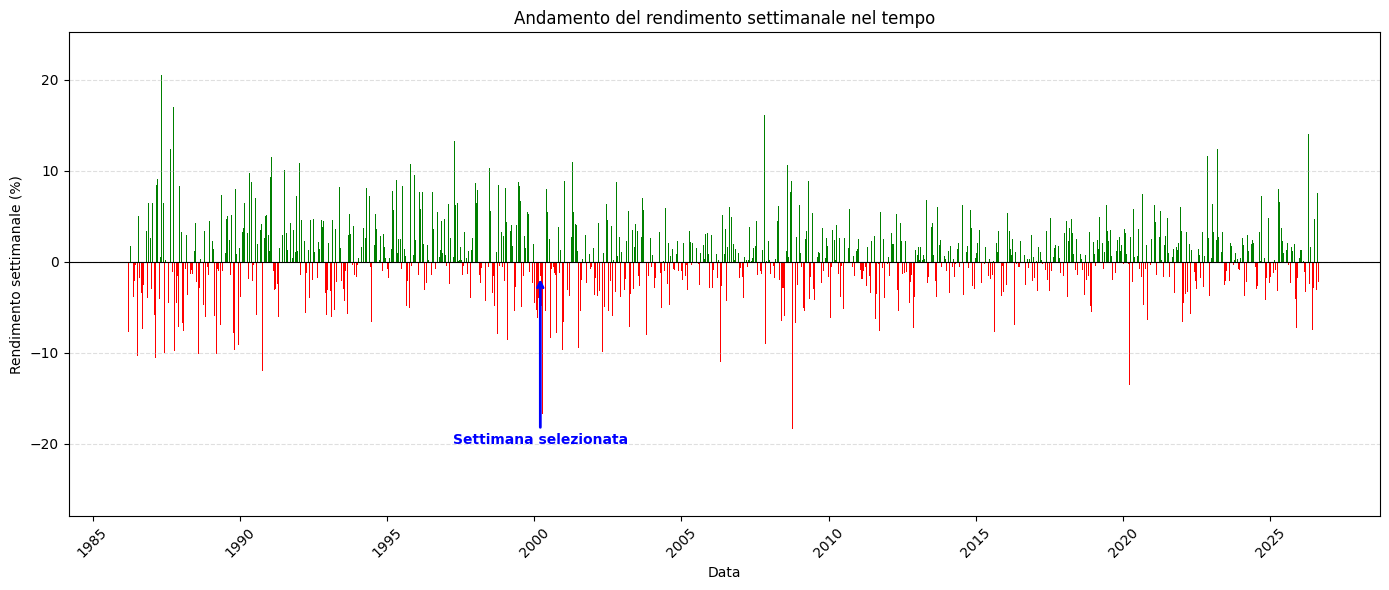

In [24]:
# @title Visualizza il rendimento di una specifica settimana
# @markdown Inserire l'anno ed il numero della settimana per cui si vuole visualizzare il rendimento

Anno = 2000 # @param {"type":"integer"}
Settimana = 11 # @param {"type":"integer"}

if Anno<min(lista_anni) or Anno>max(lista_anni):
  print(f"Anno non valido. Inserisci un anno tra {min(anni)} e {max(anni)}.\n")

if Settimana<min(lista_settimane) or Settimana>max(lista_settimane):
  print(f"Numero settimana non valido. Inserisci un numero tra {min(week)} e {max(week)}.\n")

inizio=0

for i in range(len(ds)):
    if datetime.strptime(ds[i][1],"%Y-%m-%d").year==Anno and ds[i][2]==Settimana:
      inizio = datetime.strptime(ds[i][0],"%Y-%m-%d")
      fine = datetime.strptime(ds[i][1],"%Y-%m-%d")
      close_sett = float(ds[i][3])
      rend_sett = float(ds[i][4])
      print(f"Data inizio settimana: {inizio}")
      print(f"Data fine settimana: {fine}")
      print(f"Prezzo di chiusura: {close_sett:.2f}")
      print(f"Rendimento settimanale: {rend_sett*100:.4f}%")
    else:
      continue

if inizio==0:
  print("Dati non disponibili per il periodo selezionato")
  print(f"Inserire una data compresa tra {ds[0][0]} e {lista_date[-1]}")
else:
# GRAFICO DELL'ANDAMENTO DEL RENDIMENTO SETTIMANALE
    date_settimane = []
    rendimenti_settimanali = []
    for riga in ds:
        data_fine = datetime.strptime(riga[1], "%Y-%m-%d")
        date_settimane.append(data_fine)
        rendimenti_settimanali.append(float(riga[4]) * 100)
    # Colori delle barre
    colori = ["green" if rendimento >= 0 else "red" for rendimento in rendimenti_settimanali]

    plt.figure(figsize=(14, 6))
    plt.bar(date_settimane, rendimenti_settimanali, color=colori,width=5)
    # Linea orizzontale dello zero
    plt.axhline(y=0, color="black",linewidth=0.8)
    # FRECCIA SULLA SETTIMANA SELEZIONATA
    for i, data in enumerate(date_settimane):
        if data.year == Anno and ds[i][2] == Settimana:
            rendimento = rendimenti_settimanali[i]
            # Posizione verticale della freccia
            if rendimento >= 0:
                posizione_testo = 20
            else:
                posizione_testo = -20

            plt.annotate("Settimana selezionata", xy=(data, rendimento), xytext=(data, posizione_testo), ha="center",
                         fontsize=10, fontweight="bold", color="blue",
                         arrowprops=dict(arrowstyle="->", color="blue", linewidth=2)
                        )

    plt.title("Andamento del rendimento settimanale nel tempo")
    plt.xlabel("Data")
    plt.ylabel("Rendimento settimanale (%)")

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
